## 🗺️ 오늘의 여정

이 노트북에서 우리는 **1997년 노벨 경제학상**을 받은 아이디어를 직접 코드로 재현합니다.

| 단계 | 내용 | 핵심 질문 |
|---|---|---|
| 1 | 주가 시뮬레이션 (GBM) | 미래 주가를 어떻게 흉내낼까? |
| 2 | 델타 헤징 | 옵션 판 사람은 어떻게 위험을 없앨까? |
| 3 | 헤징 비용의 분포 | 헤징에 드는 돈은 얼마일까? |
| 4 | Black-Scholes 공식 | 그 비용이 바로 옵션의 **가격**! |
| 5 | 옵션 전략 복제 | 주식만으로 복잡한 상품 만들기 |

---

### 📌 먼저 알아야 할 것: 콜옵션(Call Option)이란?

> **콜옵션** = 정해진 날짜(만기 $T$)에, 정해진 가격(행사가격 $K$)으로 주식을 **살 수 있는 권리** (의무 아님!)

만기일에 주가가 $S_T$라면, 콜옵션을 가진 사람의 이익(payoff)은:

$$\text{콜옵션 payoff} = \max(S_T - K,\ 0)$$

- 주가가 $K$보다 **높으면**: $K$에 사서 $S_T$에 팔면 되니까 $S_T - K$ 만큼 이득
- 주가가 $K$보다 **낮으면**: 권리를 포기하면 그만. 손해는 $0$

**오늘의 핵심 질문**: 이런 "권리"는 얼마에 사고팔아야 공정할까? 🤔


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

## 1️⃣ 주가 시뮬레이션 — 기하 브라운 운동 (GBM)

미래 주가는 아무도 모릅니다. 하지만 주가의 **움직임의 패턴**은 수학으로 모델링할 수 있습니다.
가장 유명한 모델이 **기하 브라운 운동(Geometric Brownian Motion, GBM)** 입니다.

### 아이디어: 수익률 = 추세 + 랜덤 충격

짧은 시간 $\Delta t$ 동안의 주가 수익률을 이렇게 씁니다:

$$\underbrace{\frac{\Delta S}{S}}_{\text{수익률}} = \underbrace{\mu \, \Delta t}_{\text{예측 가능한 추세}} + \underbrace{\sigma \sqrt{\Delta t}\; Z}_{\text{랜덤 충격}}, \qquad Z \sim N(0, 1)$$

| 기호 | 이름 | 의미 |
|---|---|---|
| $\mu$ | 드리프트(drift) | 평균적으로 오르는 속도 (여기선 이자율 $r$ 사용) |
| $\sigma$ | 변동성(volatility) | 랜덤 충격의 크기 — 지난 시간에 배운 **수익률의 표준편차**! |
| $Z$ | 표준정규분포 난수 | 매일 새로 던지는 "주사위" |
| $\sqrt{\Delta t}$ | | 시간이 길수록 불확실성이 커짐 (단, $\Delta t$가 아니라 $\sqrt{\Delta t}$에 비례) |

수학자들은 $\Delta t \to 0$의 극한을 취해 이렇게 씁니다 (미분방정식 버전):

$$dS_t = \mu S_t \, dt + \sigma S_t \, dW_t$$

> 💡 겁먹지 마세요! 코드에서는 그냥 **"어제 가격 × (1 + 오늘의 랜덤 수익률)"** 을 하루씩 반복할 뿐입니다:
> $$S_{j+1} = S_j \times (1 + \underbrace{r\,\Delta t + \sigma\sqrt{\Delta t}\, Z_j}_{\text{코드의 } rv})$$

먼저 시뮬레이션에 쓸 값들을 정합니다.


In [2]:
S0 = 100 # 기초자산의 초기 가격
r = 0.00 # 이자율
sig = 0.2 # 주식의 변동성

M = 2000 # 시뮬레이션 횟수 (number of paths)
T = 30/365 # 만기까지 남은 시간
N = 30 # 한달이라는 시간을 30개로 나누어서 보자

dt = T / N # 지금 이 세팅에서는 1-day
rdt = r * dt
sigsdt = sig * np.sqrt(dt)

### 몬테카를로 시뮬레이션: 평행우주 2000개 만들기

주가의 미래는 랜덤이니까, **한 번이 아니라 2000번** 시뮬레이션해서 "가능한 미래들"을 모두 살펴봅니다.
이런 방법을 **몬테카를로 시뮬레이션**이라고 부릅니다 (카지노로 유명한 모나코의 도시 이름에서 유래 🎰).

- `np.random.seed(100)`: 난수의 시작점을 고정 → 누가 실행해도 같은 결과 (재현성)
- `rv`: 매일의 랜덤 수익률 $r\Delta t + \sigma\sqrt{\Delta t} Z$ 를 2000경로 × 30일치 미리 생성
- 이중 for문: 각 경로($i$)마다, 하루씩($j$) $S_{j+1} = S_j(1 + rv)$ 를 반복

> 🤔 **생각해 보기**: 그래프에서 2000개의 "가능한 미래"가 부채꼴로 퍼져 나갑니다. 시간이 지날수록 퍼짐이 커지는 이유는 무엇일까요?


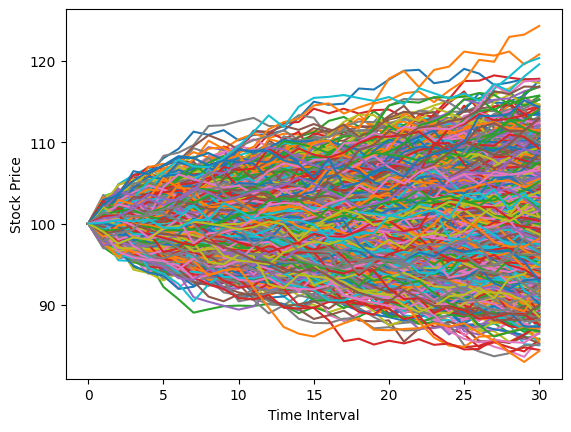

In [3]:
np.random.seed(100)

S = np.empty([M,N+1])
rv = np.random.normal(rdt, sigsdt,[M,N])

for i in range(M):
    S[i, 0] = S0
    for j in range(N):
        S[i, j+1] = S[i, j] * (1+rv[i,j])

for i in range(M):
    plt.plot(S[i,:])

plt.ylabel("Stock Price")
plt.xlabel("Time Interval")
plt.show()

---

## 2️⃣ 델타 헤징 — 옵션 판 사람의 생존 전략

여러분이 은행이고, 누군가에게 콜옵션을 **팔았다**고 합시다. 만기에 주가가 폭등하면 큰 손해입니다. 어떻게 위험을 없앨까요?

**아이디어**: 주가가 오르면 나도 손해를 보니까, **주식을 미리 조금 사두면** 그 손해를 상쇄할 수 있다!

그럼 주식을 **몇 주** 사야 할까요? 그 답이 바로 **델타($\Delta$)** 입니다.

$$\Delta = N(d_1), \qquad d_1 = \frac{\ln(S/K) + (r + \tfrac{1}{2}\sigma^2)(T-t)}{\sigma\sqrt{T-t}}$$

- $N(\cdot)$ 은 표준정규분포의 누적확률 함수 → **델타는 항상 0과 1 사이!**
- 직관: 델타 ≈ "이 옵션이 행사될 것 같은 정도"
  - 주가 ≫ 행사가격: 행사가 거의 확실 → $\Delta \approx 1$ (주식 1주를 통째로 들고 있어야 함)
  - 주가 ≪ 행사가격: 행사 가능성 희박 → $\Delta \approx 0$ (주식이 필요 없음)

그런데 주가는 매일 변하고, 델타도 매일 변합니다. 그래서 **매일 델타를 다시 계산해서 주식을 사고팔아 수량을 맞춥니다.**
이것이 **동적 델타 헤징(dynamic delta hedging)** 입니다.

### 헤징에 드는 누적 비용

매일 "새 델타 − 어제 델타"만큼 주식을 추가로 사면(음수면 팜), 총비용은 아래처럼 쌓입니다:


$$
(\Delta_0 - 0)S_1 + (\Delta_1 - \Delta_0)S_1 + (\Delta_2 - \Delta_1)S_2 + \cdots + (\Delta_{T-1} - \Delta_{T-2})S_{T-1} + (\Delta_T - \Delta_{T-1})S_T
$$

### 한 경로에서 직접 따라가 보기

2000개 경로 중 하나(`m = 2`)를 골라 30일간의 헤징 과정을 하루씩 출력해 봅니다.

출력되는 네 개의 숫자: **오늘 주가 · 오늘 델타 · 오늘 추가 매수량(델타 변화) · 누적 비용**

> 🤔 **생각해 보기**: 주가가 오르는 날 델타는 어떻게 변하나요? "오르면 더 사고, 내리면 판다"는 패턴이 보이나요?


In [4]:
m = 2

K = 100 # call option의 strike price


hedge = 0 # 이전의 delta 값 / 초기 delta = 0 (시작할 때 시점에는 주식을 하나도 안가지고 있다)
cost = 0 # 초기 cost = 0

for j in range(N):
    d1 = (np.log(S[m,j]/K)+(r+0.5*sig**2)*(T-j*dt))/(sig*np.sqrt(T-j*dt))
    delta = norm.cdf(d1) # call option의 delta (N(d1))
    cost = cost + (delta - hedge) * S[m,j] # cummulative cost
    print(S[m,j], delta, delta-hedge, cost)
    hedge = delta

100.0 0.5114357531402248 0.5114357531402248 51.143575314022485
99.07689125608613 0.4457845248869264 -0.06565122825329844 44.63905571154194
99.09622328188574 0.4458319533501736 4.7428463247234376e-05 44.643755693125804
99.34296012412267 0.46255880839794566 0.01672685504777205 46.305450987138606
99.35705020332723 0.4624952386181039 -6.35697798417878e-05 46.299134881331454
97.65590804354834 0.33468991606814263 -0.12780532254996124 33.81819005491641
96.58840312884242 0.25746037968492685 -0.07722953638321578 26.35871246128076
97.20826735055189 0.294987255413672 0.037526875728745135 30.006635029951553
97.95744645222175 0.3461476106246084 0.051160355210936426 35.018172786003504
99.01051887469114 0.4272810828430562 0.0811334722184478 43.05123996845736
97.5260683681879 0.3044409335950963 -0.12284014924795994 31.071123174542414
95.64630801048182 0.17037492065799853 -0.13406601293709774 18.248204007423524
96.01286665624016 0.18568765993994163 0.0153127392819431 19.718424002242497
95.6793945959929

### 만기일의 정산

만기가 되면 옵션 판 사람의 상황은 둘 중 하나입니다:

| 만기 상황 | 옵션 산 사람 | 옵션 판 사람(나) |
|---|---|---|
| $S_T > K$ (행사됨) | 권리 행사! $K$를 내고 주식 받아감 | 들고 있던 주식(≈1주)을 넘기고 $K$를 받음 |
| $S_T < K$ (행사 안 됨) | 권리 포기 | 들고 있던 주식(≈0주)을 시장에 되팖 |

이 마지막 정산까지 반영한 **최종 비용**을 계산합니다. (이번엔 부호를 바꿔 `(hedge-delta)`로 쓰고 마지막에 받는 돈을 더하는 방식 — 결과는 같습니다)


In [5]:
M = 64
K = 100

hedge = 0
cost = 0
for j in range(N):
    d1 = (np.log(S[M,j]/K)+(r+0.5*sig**2)*(T-j*dt))/(sig*np.sqrt(T-j*dt))
    delta = norm.cdf(d1)
    cost = cost + (hedge-delta) * S[M,j]
    hedge = delta
    #print(S[M,j], delta, cost)

if S[M,N] > K: # 만기시점의 기초자산의 가격이 행사가격보다 크면 행사가격만큼 받고 기초자산을 상대방에게 넘기겠죠?
    delta = 1 # 만기시점에 그 주식을 가지고 있어야하기 때문에 delta가 1에 가까움
    cost = cost + K
else: # 반대로 행사가격보다 작을 때
    delta = 0 # 델타는 틀림없이 0에 가까움
    cost = cost + S[M,N] * hedge

print(S[M,N], 0, cost)


98.61327867199607 0 -2.3635147821939313


---

## 3️⃣ 헤징 비용의 분포 — 히스토그램으로 보기

한 경로의 비용은 우연에 좌우됩니다. 그래서 **여러 경로에서 최종 손익(P&L)을 모아 히스토그램**을 그려봅니다.
(지난 시간에 배운 그 히스토그램입니다! 📊)

주목할 것 두 가지:

1. **분포의 중심**: 경로가 달라도 헤징 비용은 대체로 비슷한 값 근처에 모입니다. → 이 값이 곧 "옵션을 만들어 파는 원가"!
2. **분포의 퍼짐**: 하루에 한 번만 리밸런싱하기 때문에 생기는 오차입니다. 더 자주(N을 크게) 리밸런싱하면 퍼짐이 줄어듭니다.

경로 수 M을 100 → 500 → 1000 → 2000으로 늘려가며 분포가 어떻게 안정되는지 관찰해 보세요.


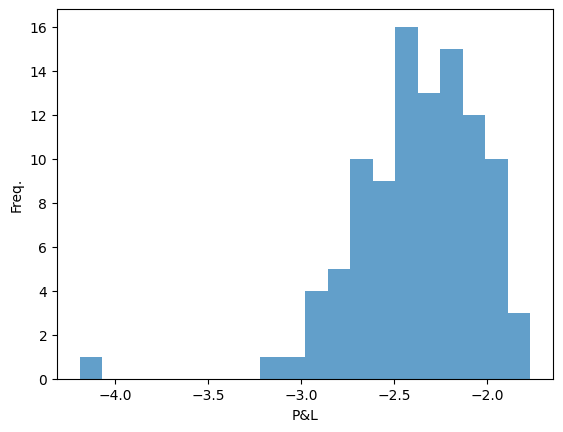

In [6]:
M = 100
a = []

K = 100

for i in range(M):
    cost = 0
    hedge = 0
    for j in range(N):
        d1 = (np.log(S[i,j]/K)+(r+0.5*sig**2)*(T-j*dt))/(sig*np.sqrt(T-j*dt))
        delta = norm.cdf(d1)
        cost = cost + (hedge-delta) * S[i,j]
        hedge = delta
    if S[i,N] > K:
        cost = cost + (hedge-1)*S[i,N] + K
        #print(hedge)
    else:
        cost = cost + (hedge-0)*S[i,N]
        #print(hedge)


    a.append(cost)

plt.hist(a, bins=20, alpha=0.7)
plt.xlabel('P&L')
plt.ylabel('Freq.')
plt.show()

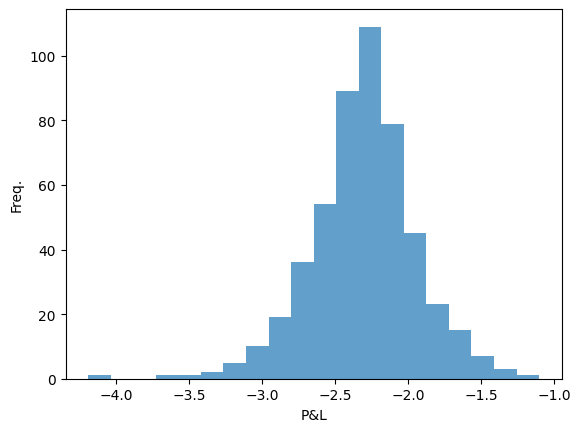

In [7]:
M = 500
a = []

K = 100

for i in range(M):
    cost = 0
    hedge = 0
    for j in range(N):
        d1 = (np.log(S[i,j]/K)+(r+0.5*sig**2)*(T-j*dt))/(sig*np.sqrt(T-j*dt))
        delta = norm.cdf(d1)
        cost = cost + (hedge-delta) * S[i,j]
        hedge = delta
    if S[i,N] > K:
        cost = cost + (hedge-1)*S[i,N] + K
        #print(hedge)
    else:
        cost = cost + (hedge-0)*S[i,N]
        #print(hedge)


    a.append(cost)

plt.hist(a, bins=20, alpha=0.7)
plt.xlabel('P&L')
plt.ylabel('Freq.')
# plt.title('Stock Price Sample Paths')
plt.show()

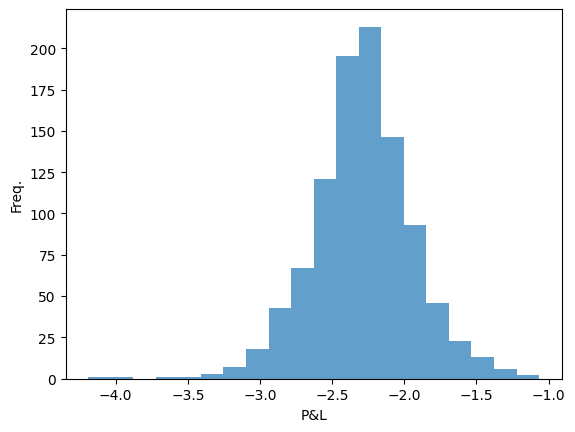

In [8]:
M = 1000
a = []

K = 100

for i in range(M):
    cost = 0
    hedge = 0
    for j in range(N):
        d1 = (np.log(S[i,j]/K)+(r+0.5*sig**2)*(T-j*dt))/(sig*np.sqrt(T-j*dt))
        delta = norm.cdf(d1)
        cost = cost + (hedge-delta) * S[i,j]
        hedge = delta
    if S[i,N] > K:
        cost = cost + (hedge-1)*S[i,N] + K
        #print(hedge)
    else:
        cost = cost + (hedge-0)*S[i,N]
        #print(hedge)


    a.append(cost)

plt.hist(a, bins=20, alpha=0.7)
plt.xlabel('P&L')
plt.ylabel('Freq.')
# plt.title('Stock Price Sample Paths')
plt.show()

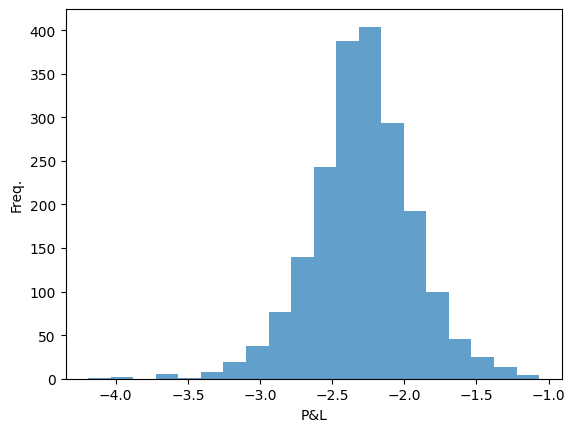

In [9]:
M = 2000
a = []

K = 100

for i in range(M):
    cost = 0
    hedge = 0
    for j in range(N):
        d1 = (np.log(S[i,j]/K)+(r+0.5*sig**2)*(T-j*dt))/(sig*np.sqrt(T-j*dt))
        delta = norm.cdf(d1)
        cost = cost + (hedge-delta) * S[i,j]
        hedge = delta
    if S[i,N] > K:
        cost = cost + (hedge-1)*S[i,N] + K
        #print(hedge)
    else:
        cost = cost + (hedge-0)*S[i,N]
        #print(hedge)


    a.append(cost)

plt.hist(a, bins=20, alpha=0.7)
plt.xlabel('P&L')
plt.ylabel('Freq.')
# plt.title('Stock Price Sample Paths')
plt.show()

---

## 4️⃣ 드디어 — Black-Scholes 공식

방금 시뮬레이션으로 구한 "헤징 원가"를, Black과 Scholes는 1973년에 **수학 공식 하나**로 구해냈습니다:

$$\boxed{\; C_0 = S_0 \, N(d_1) - K e^{-rT} N(d_2) \;}$$

$$d_1 = \frac{\ln(S_0/K) + (r + \tfrac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

읽는 법:

| 항 | 직관적 의미 |
|---|---|
| $S_0 N(d_1)$ | 만기에 받게 될 주식의 가치 (지금 기준) |
| $K e^{-rT} N(d_2)$ | 만기에 지불할 행사가격의 가치 (지금 기준) |
| $N(d_2)$ | (위험중립 세계에서) 옵션이 행사될 확률 |
| $e^{-rT}$ | 미래 돈을 현재 가치로 할인하는 항 |

> 💡 **핵심 통찰**: 옵션의 공정가격 = **완벽하게 델타 헤징했을 때 드는 비용**.
> 팔면서 이 가격을 받아 헤징하면, 주가가 어디로 가든 손익이 (거의) 0이 되기 때문입니다.

아래 셀에서 공식으로 계산한 값이, 위 히스토그램의 **중심**과 거의 일치하는지 확인해 보세요!


In [10]:
d1 = (np.log(S0/K)+(r+0.5*sig**2)*(T))/(sig*np.sqrt(T))
d2 = (np.log(S0/K)+(r-0.5*sig**2)*(T))/(sig*np.sqrt(T))

# BS fomula 공식에 따라 계산
S0 * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)

np.float64(2.2871506280449694)

### 헤징 포트폴리오는 옵션을 "복제"한다

이번엔 만기 정산 없이, **만기 주가($x$축) vs 헤징 포트폴리오의 가치($y$축)** 를 점으로 찍어봅니다.

주식만 사고팔았을 뿐인데, 그래프가 콜옵션의 payoff $\max(S_T - K, 0)$ 모양(하키스틱 🏒)을 그대로 그려낸다면 —
**옵션 없이 옵션을 만들어낸 것**입니다!


Text(0, 0.5, 'P&L')

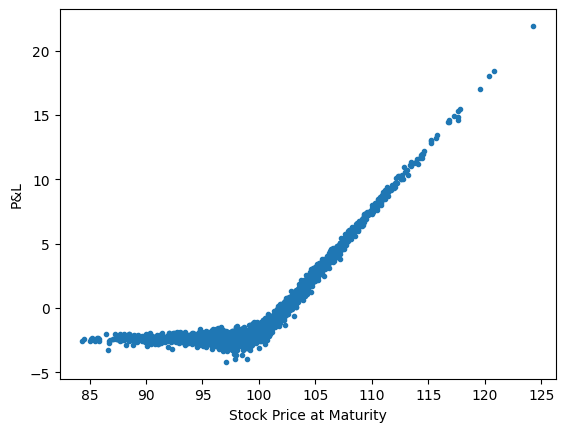

In [11]:
a = []

K = 100

for i in range(M):
    cost = 0
    hedge = 0
    for j in range(N):
        d1 = (np.log(S[i,j]/K)+(r+0.5*sig**2)*(T-j*dt))/(sig*np.sqrt(T-j*dt))
        delta = norm.cdf(d1)
        cost = cost + (hedge-delta) * S[i,j]
        hedge = delta

    cost = cost + hedge*S[i,N]


    a.append(cost)

plt.plot(S[:,-1], a, marker=".", linestyle='none')
plt.xlabel("Stock Price at Maturity")
plt.ylabel("P&L")


- N을 점점 크게 할수록 call option의 payoff에 정확하게 근사함.

- 위와 같은 delta-hedging 과정을 통해 시장에 call option이 없어도 call option을 하나 가진거와 같음. (주식만 가지고 call option의 payoff를 만들 수 있음. = 복제 포트폴리오)

### Replication of Options Strategies

- reference: https://www.investopedia.com/trading/options-strategies/

#### (참고) Long Call Butterfly Spread

행사가격이 다른 콜옵션 3개를 조합하면 재미있는 모양의 payoff를 만들 수 있습니다:

$$\text{Butterfly payoff} = \max(S_T - K_1, 0) - 2\max(S_T - K_2, 0) + \max(S_T - K_3, 0)$$

($K_1 < K_2 < K_3$: 낮은 행사가 콜 1개 매수 + 중간 행사가 콜 2개 매도 + 높은 행사가 콜 1개 매수)

이 전략의 델타는 각 옵션 델타의 같은 조합: $\Delta = \Delta_1 - 2\Delta_2 + \Delta_3$.
이 델타로 헤징하면 **나비(🦋) 모양 payoff**도 주식만으로 복제됩니다. 주가가 $K_2$ 근처에 머물 것 같을 때 쓰는 전략입니다.


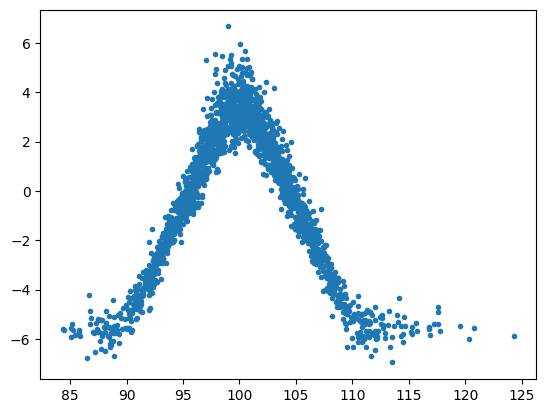

In [12]:
a = []

K_1 = 90
K_2 = 100
K_3 = 110

for i in range(M):
    cost = 0
    hedge = 0
    for j in range(N):
        d1_1 = (np.log(S[i,j]/K_1)+(r+0.5*sig**2)*(T-j*dt))/(sig*np.sqrt(T-j*dt))
        delta_1 = norm.cdf(d1_1)
        d1_2 = (np.log(S[i,j]/K_2)+(r+0.5*sig**2)*(T-j*dt))/(sig*np.sqrt(T-j*dt))
        delta_2 = norm.cdf(d1_2)
        d1_3 = (np.log(S[i,j]/K_3)+(r+0.5*sig**2)*(T-j*dt))/(sig*np.sqrt(T-j*dt))
        delta_3 = norm.cdf(d1_3)
        delta = delta_1 - 2*delta_2 + delta_3
        cost = cost + (hedge-delta) * S[i,j]
        hedge = delta

    cost = cost + hedge*S[i,N]


    a.append(cost)

plt.plot(S[:,-1], a, marker=".", linestyle='none')

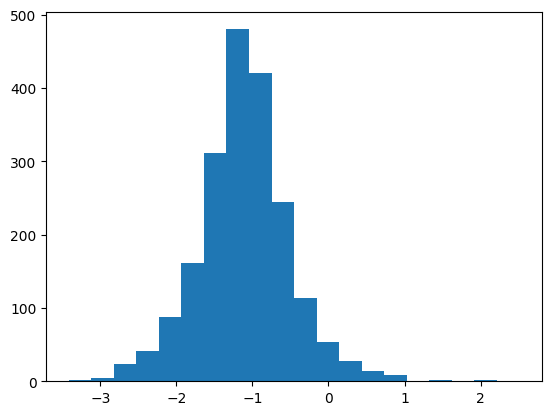

In [13]:
a = []

K_1 = 95
K_2 = 100
K_3 = 110

for i in range(M):
    cost = 0
    hedge = 0
    for j in range(N):
        d1_1 = (np.log(S[i,j]/K_1)+(r+0.5*sig**2)*(T-j*dt))/(sig*np.sqrt(T-j*dt))
        delta_1 = norm.cdf(d1_1)
        d1_2 = (np.log(S[i,j]/K_2)+(r+0.5*sig**2)*(T-j*dt))/(sig*np.sqrt(T-j*dt))
        delta_2 = norm.cdf(d1_2)
        d1_3 = (np.log(S[i,j]/K_3)+(r+0.5*sig**2)*(T-j*dt))/(sig*np.sqrt(T-j*dt))
        delta_3 = norm.cdf(d1_3)
        delta = delta_1 - 2*delta_2 + delta_3
        cost = cost + (hedge-delta) * S[i,j]
        hedge = delta


    cost = cost + hedge * S[i,N] + (- np.maximum(S[i,N]-K_1,0) + 2* np.maximum(S[i,N]-K_2,0) - np.maximum(S[i,N]-K_3,0))

    a.append(cost)

plt.hist(a, bins=20)
plt.show()

---

# 🔁 2부: 처음부터 다시, 깔끔하게

지금까지의 과정을 정리된 코드로 다시 한 번 봅니다. 흐름은 같습니다:
**GBM 시뮬레이션 → BS 공식을 함수로 정의 → 델타 헤징으로 복제 확인**


In [14]:
r = 0.00
sig = 0.2 # volatility

M = 1000 # number of paths

T = 30/365 # maturity
N = 30

dt = T/N # time interval
rdt = r*dt
sigsdt = sig * np.sqrt(dt)

S0 = 100 # initial stock price
K = 100 # strike price

## GBM Simulation

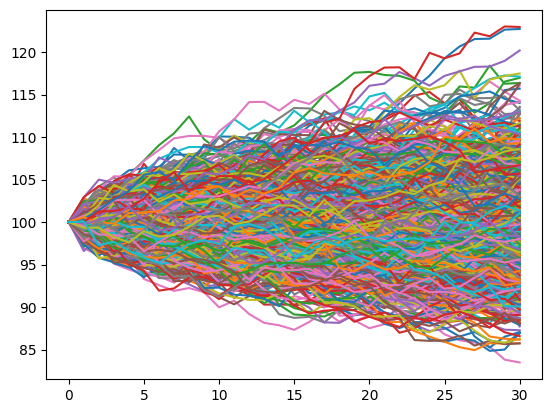

In [15]:
np.random.seed(1234)

S = np.empty([M,N+1])
rv = np.random.normal(r*dt,sigsdt,[M,N])


for i in range(M):
    S[i,0] = S0
    for j in range(N):
        S[i,j+1] = S[i,j] * (1+rv[i,j])

for i in range(M):
    plt.plot(S[i,:])

plt.show()

In [16]:
S.shape

(1000, 31)

$$
(\Delta_0 - 0)S_0 + (\Delta_1 - \Delta_0)S_1 + (\Delta_2 - \Delta_1)S_2 + \cdots + (\Delta_{T-1} - \Delta_{T-2})S_{T-1} + (\Delta_T - \Delta_{T-1})S_T
$$


### Black-Scholes 공식을 함수로

콜옵션과 함께 **풋옵션**(정해진 가격에 **팔** 권리) 가격 공식도 함수로 만들어 둡니다:

$$C_0 = S_0 N(d_1) - K e^{-rT} N(d_2) \qquad \text{(콜)}$$

$$P_0 = K e^{-rT} N(-d_2) - S_0 N(-d_1) \qquad \text{(풋)}$$

> 💡 콜과 풋은 대칭 관계입니다. 두 식을 빼면 **풋-콜 패리티** $C_0 - P_0 = S_0 - Ke^{-rT}$ 가 나옵니다.


In [17]:
# BS formula

# call option
def bscall(S, K, T, r, sig):
    d1 = (np.log(S/K)+(r+0.5*sig**2)*T)/(sig*np.sqrt(T))
    d2 = (np.log(S/K)+(r-0.5*sig**2)*T)/(sig*np.sqrt(T))
    return S*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)

# put option
def bsput(S, K, T, r, sig):
    d1 = (np.log(S/K)+(r+0.5*sig**2)*T)/(sig*np.sqrt(T))
    d2 = (np.log(S/K)+(r-0.5*sig**2)*T)/(sig*np.sqrt(T))
    return K*np.exp(-r*T)*norm.cdf(-d2)-S*norm.cdf(-d1)

In [18]:
bscall(S0, K, T, r, sig)

np.float64(2.2871506280449694)

### 최종 확인: 헤징 손익 = 0?

만기 payoff까지 정산한 뒤 **옵션 판매가격(BS 가격)** 을 빼면, 완벽한 헤징이라면 손익이 0 근처에 모여야 합니다.
$x$축(만기 주가) 어디에서든 $y$(손익)가 0 근처에 붙어 있는지 확인해 보세요.


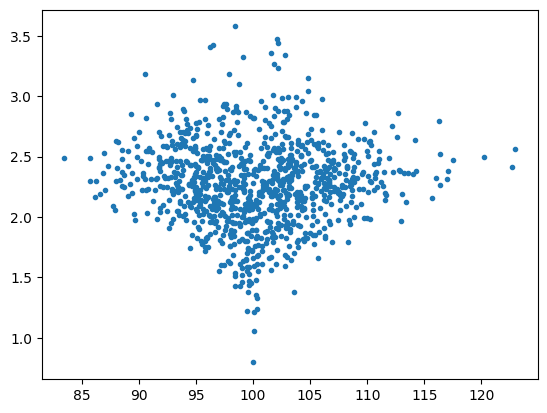

In [19]:
a = []

for i in range(M):
    cost = 0
    hedge = 0
    for j in range(N):
        d1 = (np.log(S[i,j]/K)+(r+0.5*sig**2)*(T-j*dt))/(sig*np.sqrt(T-j*dt))
        delta = norm.cdf(d1)
        cost = cost + (delta-hedge) * S[i,j] # 위에 있는 식 그대로
        hedge = delta

    # cost = cost - hedge * S[i,N] # 마지막 항
    cost = cost - hedge * S[i,N] + np.maximum(S[i,N]-K, 0)
    #cost = cost - hedge * S[i,N] + np.maximum(S[i,N]-K, 0) - bscall(S0, K, T, r, sig)

    a.append(cost)

plt.plot(S[:,-1], a, marker=".", linestyle='none')
plt.show()

기존 식에서 코드를 간결하게 만들기 위해.. 바꿔준 식. 결국 결과는 같음!

$$
(\Delta_0 - 0)S_0 + (\Delta_1 - \Delta_0)S_1 + (\Delta_2 - \Delta_1)S_2 + \cdots + (\Delta_{T-1} - \Delta_{T-2})S_{T-1} + (\Delta_T - \Delta_{T-1})S_T \\
$$

$$
\Delta_0 (S_0-S_1) + \Delta_1 (S_1-S_2) + \Delta_2 (S_2-S_3) + \cdots + \Delta_{T-1} (S_{T-1}-S_T) + \Delta_T S_T
$$

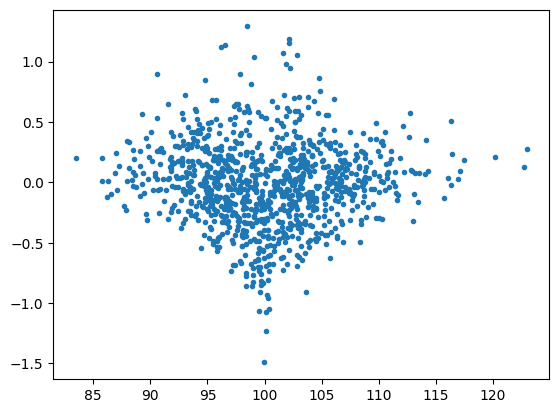

In [20]:
a = []

for i in range(M):

    cost = 0
    price = S[i,0]

    for j in range(N):
        d1 = (np.log(S[i,j]/K)+(r+0.5*sig**2)*(T-j*dt))/(sig*np.sqrt(T-j*dt))
        delta = norm.cdf(d1) # call option delta
        cost = cost + delta*(price - S[i, j+1])
        price = S[i,j+1]

    cost = cost + np.maximum(S[i,N]-K, 0) - bscall(S0, K, T, r, sig)

    a.append(cost)

plt.plot(S[:, -1], a, marker=".", linestyle='none')
plt.show()